In [22]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
initial_chamber_pressure = 2e6  # Pa
initial_thrust = 2000  # N

cstar = 1600  # m/s, characteristic velocity

throat_step = 0.0001  # m

In [24]:
def compute_throat_radius(thrust, chamber_pressure, cstar, mdot):
    """
    Compute the throat radius given thrust, chamber pressure, characteristic velocity, and mass flow rate.
    """
    throat_area = (thrust + mdot * cstar) / chamber_pressure
    throat_radius = np.sqrt(throat_area / np.pi)
    return throat_radius

In [25]:
def compute_throat_area(mdot, cstar, chamber_pressure):
    """Compute the throat area of the nozzle."""
    return mdot * cstar / chamber_pressure

def compute_chamber_pressure(mdot, cstar, throat_area):
    """Compute the chamber pressure of the nozzle."""
    return mdot * cstar / throat_area

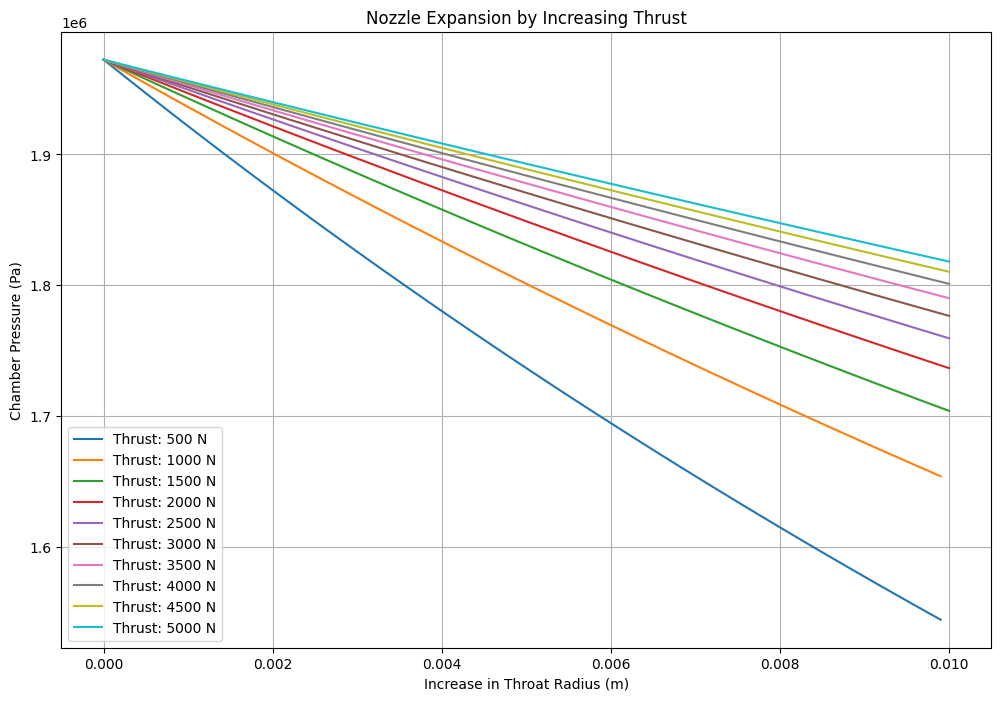

In [ ]:
for thrust in np.arange(initial_thrust, 5001, 500):
    mdot = thrust / 219 * 9.8
    throat_radius = compute_throat_radius(thrust, initial_chamber_pressure, cstar, mdot)
    final_throat_radius = throat_radius + 0.01  # m


    pressures = []
    delta_radii = []
    for expanded_throat_radius in np.arange(throat_radius, final_throat_radius, throat_step):
        throat_area = np.pi * expanded_throat_radius**2
        chamber_pressure = compute_chamber_pressure(mdot, cstar, throat_area)
        pressures.append(chamber_pressure)
        delta_radii.append(expanded_throat_radius - throat_radius)
    
    plt.plot(delta_radii, pressures, label=f'Thrust: {thrust} N')
    


plt.gcf().set_size_inches(12, 8)


#plt.xticks(np.arange(0, final_throat_radius, throat_step))
# plt.xticks(np.arange(initial_throat_radius, final_throat_radius, throat_step), 
#            [f"{x*1000:.2f}" for x in np.arange(initial_throat_radius, final_throat_radius, throat_step)])
#plt.axhline(y=1.96e6, color='red', linestyle='--', label='Current Margin of Safety')
#plt.text(final_throat_radius, 1.96e6, f'{1.96e6/1e6:.2f} MPa', color='red', va='bottom', ha='right')

# plt.grid(which='both', axis='both')
# plt.legend()
# plt.show()

plt.xlabel('Increase in Throat Radius (m)')
plt.ylabel('Chamber Pressure (MPa)')
plt.title('Nozzle Expansion by Increasing Thrust')
plt.legend()
plt.grid()
plt.show()

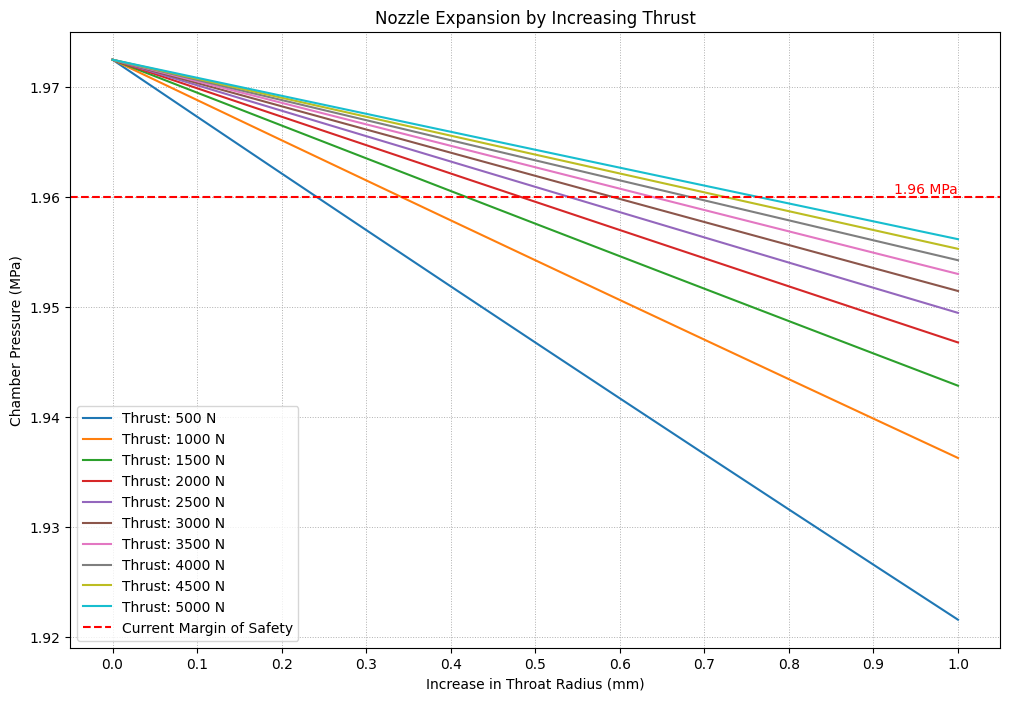

In [36]:
for thrust in np.arange(initial_thrust, 5001, 500):
    mdot = thrust / 219 * 9.8
    throat_radius = compute_throat_radius(thrust, initial_chamber_pressure, cstar, mdot)
    final_throat_radius = throat_radius + 0.001  # m

    pressures = []
    delta_radii = []
    for expanded_throat_radius in np.arange(throat_radius, final_throat_radius, throat_step):
        throat_area = np.pi * expanded_throat_radius**2
        chamber_pressure = compute_chamber_pressure(mdot, cstar, throat_area)
        pressures.append(chamber_pressure)
        delta_radii.append(expanded_throat_radius - throat_radius)
    
    plt.plot(np.array(delta_radii)*1000, np.array(pressures)/1e6, label=f'Thrust: {thrust} N')  # x in mm, y in MPa

plt.gcf().set_size_inches(12, 8)

plt.axhline(y=1.96, color='red', linestyle='--', label='Current Margin of Safety')
plt.text((final_throat_radius-throat_radius)*1000, 1.96, '1.96 MPa', color='red', va='bottom', ha='right')

plt.xlabel('Increase in Throat Radius (mm)')
plt.ylabel('Chamber Pressure (MPa)')
plt.title('Nozzle Expansion by Increasing Thrust')

plt.xticks(np.arange(0, (final_throat_radius-throat_radius)*100+1, 0.1))
plt.grid(which='both', axis='both', linestyle=':', linewidth=0.7)
plt.legend()
plt.show()
